In [30]:
import wikipediaapi
import nltk #language processing
import ssl
import re
import numpy as np
from nltk.corpus import stopwords # am, is ,a re,the like words 
from nltk.stem import WordNetLemmatizer # get base form of every word running -> run, played -> play
from sklearn.feature_extraction.text import TfidfVectorizer #words get more weight if there rare
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score #like elbow rule, use to find best k value
import matplotlib.pyplot as plt


try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:   
    ssl._create_default_https_context = _create_unverified_https_context


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('NLTK resources downloaded successfully.')



NLTK resources downloaded successfully.


[nltk_data] Downloading package stopwords to /home/sandula-
[nltk_data]     sanchana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/sandula-
[nltk_data]     sanchana/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/sandula-
[nltk_data]     sanchana/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [31]:
#wiki_api=wikipediaapi.Wikipedia('.ipynb','en') #en for english language
#page=wiki_api.page('Machine learning') #get the page of machine learning
#text=page.text #get the text of the page
#print(text)



In [32]:
# List of articles to cluster. We've chosen topics in astronomy, biology, and computer science
article_titles = [
    "Galaxy", "Black hole", "Supernova",              # Astronomy
    "DNA", "Photosynthesis", "Evolution",             # Biology
    "Machine learning", "Artificial intelligence", "Computer programming"  # Computer Science
]

wiki_api=wikipediaapi.Wikipedia('.ipynb','en') #en for english language

documents=[]


for title in article_titles:
    page=wiki_api.page(title) #get the page of the article
    if page.exists(): #check if the page exists
          text=page.text #get the text of the page
          documents.append(text) #add the text to the documents list
          print(f"Page '{title}' added to documents.")

    else:
          print(f"Page '{title}' does not exist.")

print(f"Total documents collected: {len(documents)}")          


    

Page 'Galaxy' added to documents.
Page 'Black hole' added to documents.
Page 'Supernova' added to documents.
Page 'DNA' added to documents.
Page 'Photosynthesis' added to documents.
Page 'Evolution' added to documents.
Page 'Machine learning' added to documents.
Page 'Artificial intelligence' added to documents.
Page 'Computer programming' added to documents.
Total documents collected: 9


In [33]:
stop_words=set(stopwords.words('english')) #get the stop words of english language
print(f"Number of stop words: {len(stop_words)}")
print(stop_words)

lematizer=WordNetLemmatizer() #create a lemmatizer object

def preprocess(text):
    text=text.lower() #convert the text to lowercase
    text=re.sub(r'[^a-z\s]','',text) #remove the special characters and numbers
    words=text.split() #split the text into words #tokenization
    preprocessed_words=[
        lematizer.lemmatize(word) for word in words if word not in stop_words
    ]
    #print(preprocessed_words)
    return ' '.join(preprocessed_words) #join the preprocessed words and return the preprocessed text


preprocesses_documents=[
    preprocess(doc) for doc in documents
]

print("Preprocessing completed.")
print(preprocesses_documents)



Number of stop words: 198
{'couldn', "we're", 'the', 'has', 'against', 'about', "it'll", 'being', "she'd", "shouldn't", 'been', 'yours', 'but', 'we', 'because', "they'd", 'only', 'at', "should've", "you're", 'my', 'its', 'a', "couldn't", 'there', 'yourselves', "it's", "we'd", 'yourself', 'from', 'how', 'doing', 'few', 'after', "mustn't", 'ain', "haven't", 'nor', 'he', 'ourselves', 'some', "they'll", "we'll", 'don', 'with', 'what', 'until', 'can', 'both', 'to', 'too', "didn't", 'no', "they've", 'should', 'same', 'before', 'himself', 'wasn', 'her', 'theirs', 'hers', 'then', "it'd", 'was', 'any', 'not', 'be', 'd', 'myself', 'mustn', 'you', "she's", 'ours', 'than', 'most', "they're", 'shouldn', 'above', "hadn't", 'while', 'ma', "shan't", 'it', 'through', 'will', 'down', 'itself', 'if', 'during', 'doesn', 'our', "wasn't", 'again', 'once', 'over', 'by', 'me', 'won', 'further', "hasn't", "we've", 'just', 'up', 'am', 'were', 've', 'under', 's', 'between', 'other', 'had', "mightn't", 'out', 'th

In [34]:
# --- Step 4: Convert Text to Vectors ---

# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=1000)  # Limit to the top 1000 features

# Create the TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(preprocesses_documents)

print(tfidf_matrix)

print("TF-IDF matrix created successfully.")
print(f"Shape of the matrix: {tfidf_matrix.shape}")

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5170 stored elements and shape (9, 1000)>
  Coords	Values
  (0, 377)	0.8686503426613954
  (0, 909)	0.011548988132747916
  (0, 871)	0.28770584597702265
  (0, 877)	0.024897621286473114
  (0, 775)	0.0048885341738206
  (0, 469)	0.0268869379560133
  (0, 380)	0.06267289131017946
  (0, 271)	0.0293312050429236
  (0, 217)	0.0391082733905648
  (0, 548)	0.035315175896937376
  (0, 107)	0.008724253599762448
  (0, 934)	0.010594552769081212
  (0, 399)	0.016598414190982076
  (0, 992)	0.005297276384540606
  (0, 552)	0.002181063399940612
  (0, 570)	0.1355537158930203
  (0, 762)	0.002887247033186979
  (0, 983)	0.07073755231308099
  (0, 193)	0.005297276384540606
  (0, 852)	0.0146656025214618
  (0, 308)	0.008828793974234344
  (0, 571)	0.015879858682528385
  (0, 741)	0.004330870549780468
  (0, 842)	0.02154380638787419
  (0, 272)	0.05532804730327359
  :	:
  (8, 635)	0.03131220880148297
  (8, 87)	0.006916510262183017
  (8, 720)	0.5009953408237275
 

In [ ]:
# --- Step 5: Run K-Means ---

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=5) #it means:run K-Means 5 separate times ,each time with different initial starting centroids ,keep the best result

## The below line is functionally identical to the above line
# kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)

kmeans.fit(tfidf_matrix)

# Get the cluster assignments for each document
labels = kmeans.labels_
print("Best labels:", kmeans.labels_) # 2,2,2 mean first 3 docs are cluster 2
print("Best inertia:", kmeans.inertia_)

Best labels: [2 2 2 0 0 0 1 1 1]
Best inertia: 4.618861714454949


In [36]:
# --- Step 6: Evaluation Model performance ---

# --- 1. Calculate WCSS (Within-Cluster Sum of Squares) ---
# This is already calculated automatically when you fit the model!
# It is stored in the variable 'kmeans.inertia_'
# A lower WCSS indicates that the clusters are tighter and better defined.
# Inertia (WCSS): lower values mean points are closer to their cluster centers
wcss = kmeans.inertia_

# --- 2. Calculate Silhouette Score ---
# This measures how well-separated the clusters are.
# It takes the data (tfidf_matrix) and the labels the model assigned.
# Silhouette score: higher values mean clusters are more compact and better separated
sil_score = silhouette_score(tfidf_matrix, kmeans.labels_)

print("--- Model Evaluation Metrics ---")
print(f"WCSS (Inertia): {wcss:.4f}")
print(f"Silhouette Score: {sil_score:.4f}")

--- Model Evaluation Metrics ---
WCSS (Inertia): 4.6189
Silhouette Score: 0.0994


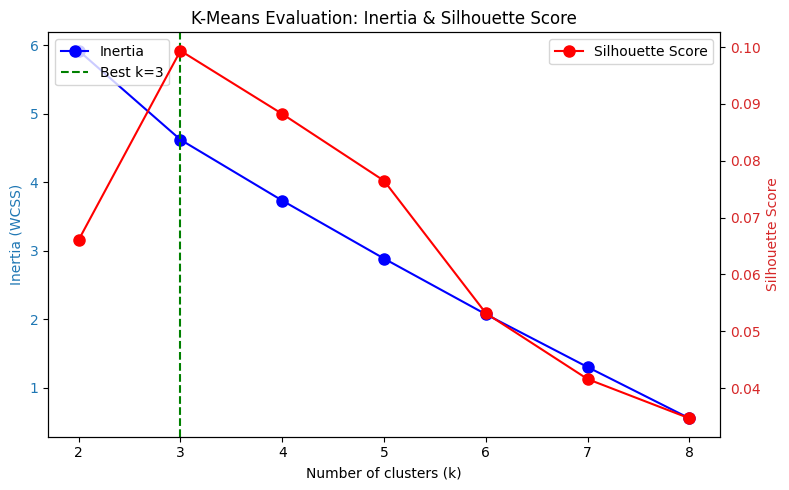

Suggested optimal number of clusters by silhouette score: k = 3


In [37]:
# --- Step 7: Evaluate the optimal number of clusters (k) for K-Means using two metrics ---

# 1. Inertia (WCSS) – measures within-cluster compactness (used in the Elbow method).
# 2. Silhouette Score – measures how well-separated the clusters are.
# The code runs K-Means for different k values, stores both metrics, and plots them
# to help visually identify the best number of clusters.

# Number of documents
num_docs = tfidf_matrix.shape[0]

# --- Step 1: Define range of k ---
k_values = range(2, num_docs)  # 2 to 8

inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix)
    inertia_values.append(kmeans.inertia_)
    sil_score = silhouette_score(tfidf_matrix, labels)
    silhouette_values.append(sil_score)

# --- Step 3: Plot both curves ---
fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(k_values, inertia_values, 'bo-', markersize=8, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('K-Means Evaluation: Inertia & Silhouette Score')

# Create second y-axis for silhouette
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_values, silhouette_values, 'ro-', markersize=8, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

# Optional: mark best k according to silhouette
best_k_index = silhouette_values.index(max(silhouette_values))
best_k = k_values[best_k_index]
ax1.axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')

# Legends
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

print(f"Suggested optimal number of clusters by silhouette score: k = {best_k}")

In [ ]:
# --- Step 8: Putting the Model to Work - Predicting on New Documents ---
# Now for the exciting part! We can take our final "trained" model and
# use it to instantly categorize a brand new, unseen document.
# Let's see which topic cluster it belongs to!

# --- Define your new document ---
new_text = "An algorithm is a set of well-defined instructions designed to perform a specific task or solve a computational problem. In computer science, the study of algorithms is fundamental to creating efficient and scalable software. Data structures, such as arrays and hash tables, are used to organize data in a way that allows these algorithms to access and manipulate it effectively."

# --- Apply the SAME preprocessing ---
# We use the preprocess_text function we defined earlier
processed_new_text = preprocess(new_text)
print(f"Cleaned Text: {processed_new_text}")

# --- Use the FITTED vectorizer to transform the text ---
# IMPORTANT: Use .transform(), not .fit_transform()
# This ensures it uses the same vocabulary learned from the original documents.
new_tfidf_vector = vectorizer.transform([processed_new_text])

print(f"\nShape of the new vector: {new_tfidf_vector.shape}")

# --- Now you can predict its cluster ---
predicted_label = kmeans.predict(new_tfidf_vector)

print(f"\nThe new document belongs to cluster: {predicted_label[0]}") # 1 mean cluster 1, so computer science cluster

Cleaned Text: algorithm set welldefined instruction designed perform specific task solve computational problem computer science study algorithm fundamental creating efficient scalable software data structure array hash table used organize data way allows algorithm access manipulate effectively

Shape of the new vector: (1, 1000)

The new document belongs to cluster: 1
